N=10: entropy=0.971, scaled_mean=0.579, simple_mean=9.775
N=100: entropy=1.864, scaled_mean=0.149, simple_mean=39.89875
N=1000: entropy=1.809, scaled_mean=0.034, simple_mean=34.018
N=10000: entropy=1.878, scaled_mean=0.032, simple_mean=31.32553003533569
N=100000: entropy=1.851, scaled_mean=0.023, simple_mean=29.27763257289621


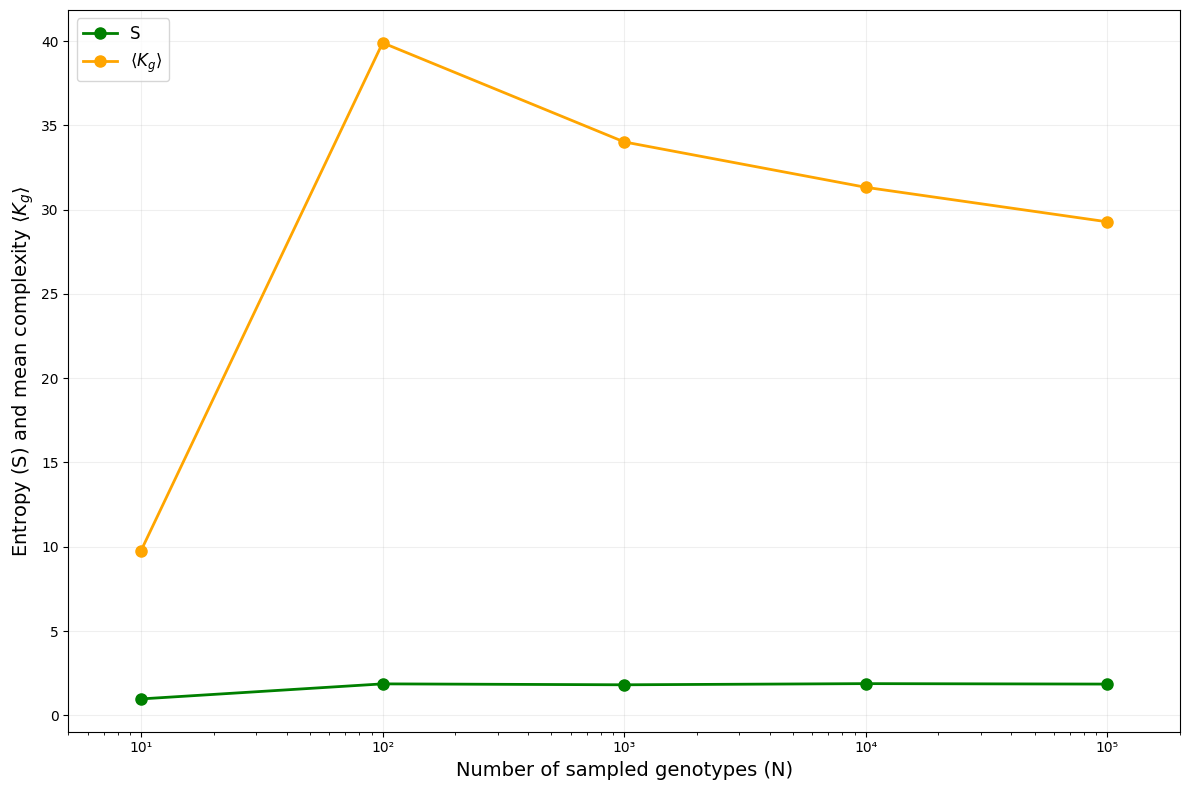

All plots created successfully!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def create_plot(N_values, entropies, scaled_means=None, simple_means=None,
                filename_suffix="", log_y=False, simple_mean_only=False):
    plt.figure(figsize=(12, 8))
    
    plt.semilogx(N_values, entropies, 'o-', linewidth=2, markersize=8,
                 color='green', label='S')
    
    if scaled_means is not None:
        plt.semilogx(N_values, scaled_means, 'o-', linewidth=2, markersize=8,
                 color='red', label=r'$\langle K_{g}\rangle$')
    
    if simple_means is not None:
        plt.semilogx(N_values, simple_means, 'o-', linewidth=2, markersize=8,
                     color='orange', label=r'$\langle K_{g}\rangle$')
    
    plt.xlabel('Number of sampled genotypes (N)', fontsize=14)
    plt.ylabel(r'Entropy (S) and mean complexity $\langle K_{g}\rangle$', fontsize=14)
    
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12, loc='upper left')
    plt.xlim(5, 200000)
    x_ticks = [10, 100, 1000, 10000, 100000]
    x_tick_labels = ['10¹', '10²', '10³', '10⁴', '10⁵']
    plt.xticks(x_ticks, x_tick_labels)
    plt.grid(True, which="major", ls="-", alpha=0.2)
    plt.tight_layout()
    
    return plt.gcf()

# Local path - updated to plot_b_files
base_dir = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/tooth model/plot_b/plot_b_files/plot_c")

configs = [
    {'N': 10, 'dir': '10', 'entropy_file': base_dir / '10' / '10entropy.txt',
     'scaled_mean_file': base_dir / '10' / 'scaled_mean.txt',
     'simple_mean_file': base_dir / '10' / 'simple_mean.txt'},
    {'N': 100, 'dir': '100', 'entropy_file': base_dir / '100' / '100entropy.txt',
     'scaled_mean_file': base_dir / '100' / 'scaled_mean.txt',
     'simple_mean_file': base_dir / '100' / 'simple_mean.txt'},
    {'N': 1000, 'dir': '103', 'entropy_file': base_dir / '103' / '103entropy.txt',
     'scaled_mean_file': base_dir / '103' / 'scaled_mean.txt',
     'simple_mean_file': base_dir / '103' / 'simple_mean.txt'},
    {'N': 10000, 'dir': '104', 'entropy_file': base_dir / '104' / '104_entropy.txt',
     'scaled_mean_file': base_dir / '104' / 'scaled_mean.txt',
     'simple_mean_file': base_dir / '104' / 'simple_mean.txt'},
    {'N': 100000, 'dir': '105', 'entropy_file': base_dir / '105' / '105entropy.txt',
     'scaled_mean_file': base_dir / '105' / 'scaled_mean.txt',
     'simple_mean_file': base_dir / '105' / 'simple_mean.txt'}
]

data = []

for config in configs:
    N = config['N']
    try:
        with open(config['entropy_file'], 'r') as f:
            entropy = float(f.read().strip())
        with open(config['scaled_mean_file'], 'r') as f:
            scaled_mean = float(f.read().strip())
        simple_mean = None
        if config['simple_mean_file'].exists():
            with open(config['simple_mean_file'], 'r') as f:
                simple_mean = float(f.read().strip())
        data.append((N, entropy, scaled_mean, simple_mean))
        print(f"N={N}: entropy={entropy:.3f}, scaled_mean={scaled_mean:.3f}, simple_mean={simple_mean if simple_mean is not None else 'N/A'}")
    except Exception as e:
        print(f"Warning: Could not read data for N={N}: {e}")

data.sort(key=lambda x: x[0])

N_values = [d[0] for d in data]
entropies = [d[1] for d in data]
scaled_means = [d[2] for d in data]
simple_means = [d[3] for d in data]
has_simple_means = any(sm is not None for sm in simple_means)

# Output directory for plots
output_dir = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/tooth model/plot_b")

# Create all plot variants
if has_simple_means:
    fig1 = create_plot(N_values, entropies, scaled_means=scaled_means, simple_means=simple_means)
    fig1.savefig(output_dir / "plot_c_complexity_vs_entropy_with_simple_mean.png", dpi=300, bbox_inches='tight')
    plt.close(fig1)
fig2 = create_plot(N_values, entropies, scaled_means=scaled_means, simple_means=None)
fig2.savefig(output_dir / "plot_c_complexity_vs_entropy_no_simple_mean.png", dpi=300, bbox_inches='tight')
plt.close(fig2)

# Without 10^1 point
filtered = [(N, ent, sc, sm) for (N, ent, sc, sm) in zip(N_values, entropies, scaled_means, simple_means) if N != 10]
if filtered:
    filtered_N = [d[0] for d in filtered]
    filtered_entropies = [d[1] for d in filtered]
    filtered_scaled = [d[2] for d in filtered]
    fig3 = create_plot(filtered_N, filtered_entropies, scaled_means=filtered_scaled, simple_means=None)
    fig3.savefig(output_dir / "plot_c_complexity_vs_entropy_no_10_no_simple_mean.png", dpi=300, bbox_inches='tight')
    plt.close(fig3)

# Simple mean only variants
if has_simple_means:
    fig4 = create_plot(N_values, entropies, scaled_means=None, simple_means=simple_means, simple_mean_only=True)
    fig4.savefig(output_dir / "plot_c_complexity_vs_entropy_simple_mean_only.png", dpi=300, bbox_inches='tight')
    plt.close(fig4)
    
    fig5 = create_plot(N_values, entropies, scaled_means=None, simple_means=simple_means, log_y=True, simple_mean_only=True)
    fig5.savefig(output_dir / "plot_c_complexity_vs_entropy_simple_mean_only_logy.png", dpi=300, bbox_inches='tight')
    plt.show()

print("All plots created successfully!")
